In [1]:
'''This notebook explores the sensitivity of the SIR model driven by an OU process wrt parameters'''

'This notebook explores the sensitivity of the SIR model driven by an OU process wrt parameters'

In [2]:
from diffrax import diffeqsolve, ODETerm,VirtualBrownianTree,MultiTerm,ControlTerm
from jax.scipy.stats import norm, poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt



In [3]:
def model(x0, theta, key,days, delta_t):
    gamma,xi,damping,log_mean,log_std = theta
    log_beta_damping = damping
    log_beta_mean = log_mean
    log_beta_standard_deviation = log_std

    A = jnp.exp(-log_beta_damping * delta_t)
    M = log_beta_mean * (jnp.exp(-log_beta_damping * delta_t) - 1)
    C = log_beta_standard_deviation * jnp.sqrt(
        1 - jnp.exp(-2 * log_beta_damping * delta_t)
    )

    def tau_step(state, i):
        prev_x, prev_key = state
        S, I, R, log_beta = prev_x

        N = S + I + R

        update_key, next_key = jax.random.split(prev_key, 2)
        update_keys = jax.random.split(update_key, 4)

        log_beta = A * log_beta - M + C * jax.random.normal(update_keys[0])

        dN_SI = jax.random.poisson(
            update_keys[1], jnp.exp(log_beta) * (S * I / N) * delta_t
        )
        dN_SI = jnp.minimum(dN_SI, S)

        dN_IR = jax.random.poisson(update_keys[2], I * gamma * delta_t)
        dN_IR = jnp.minimum(dN_IR, I)

        dN_RS = jax.random.poisson(update_keys[3], R * xi * delta_t)
        dN_RS = jnp.minimum(dN_RS, R)

        S = S - dN_SI + dN_RS
        I = I + dN_SI - dN_IR
        R = R + dN_IR - dN_RS

        return (jnp.array([S, I, R, log_beta]), next_key), jnp.array(
            [S, I, R, log_beta]
        )

    _,loop_val = jax.lax.scan(
        tau_step,
        init=(x0, key),
        xs=jnp.arange(0, days, delta_t),
    )

    return jnp.concatenate((x0[jnp.newaxis,:],loop_val))

We are approximating the quantities 
$$
\begin{align}
\frac{\partial \mathbb{E}[I(t;\theta)]}{\partial \theta_{i}}\bigg\rvert_{\theta = \theta^{*}} \approx \frac{1}{N} \sum\limits_{i=1}^{N} \frac{I(t;\theta_{i}+\epsilon) - I(t;\theta_{i}-\epsilon)}{2\epsilon}
\end{align}
$$

which has a bias of $\mathcal{O}(\epsilon^2)$. 

In [4]:
theta = jnp.array([0.1, 1 / 180, 1 / 35, jnp.log(0.35), 0.2])
theta_names = ['$\\gamma$','$\\xi$','$\\lambda$','$\\mu$','$\\sigma$']
delta_t = 1.0
days = 80
rng_key = jax.random.key(0)

num_models = 10_000
keys = jax.random.split(rng_key, num_models)

x0 = jnp.array([495, 5, 0, jnp.log(0.35)])
epsilon = 0.01

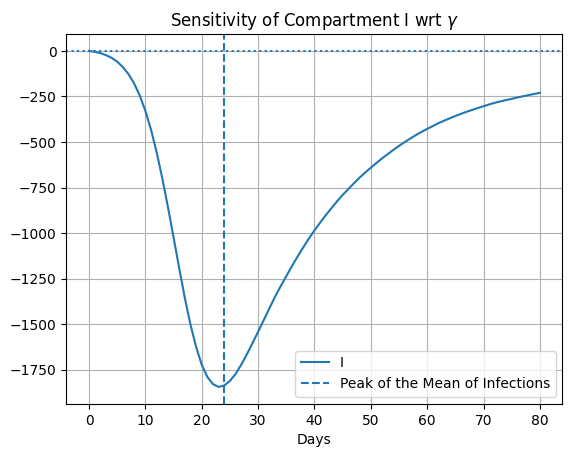

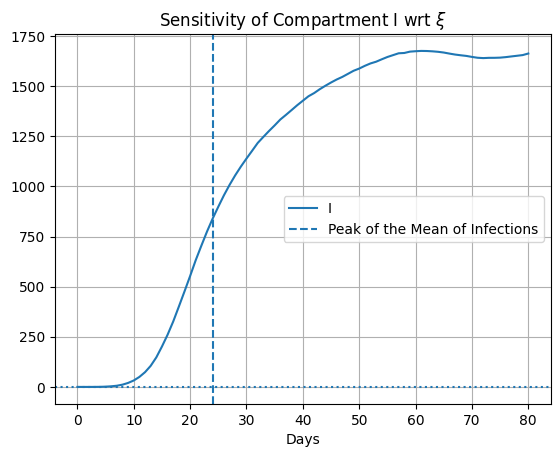

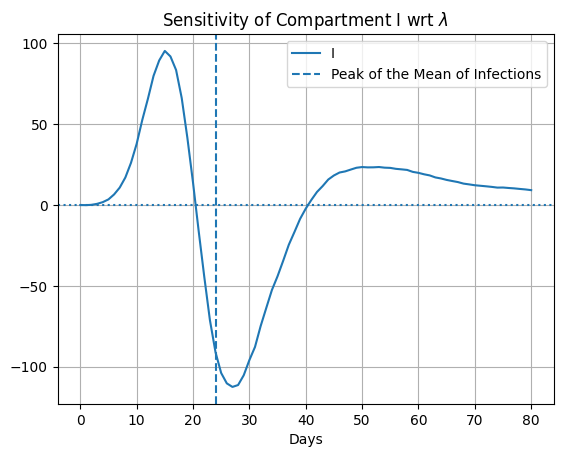

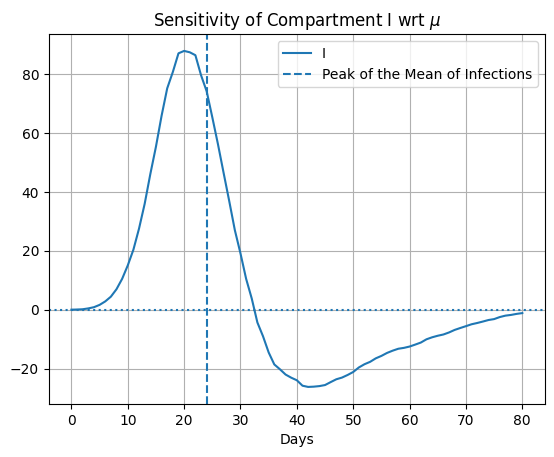

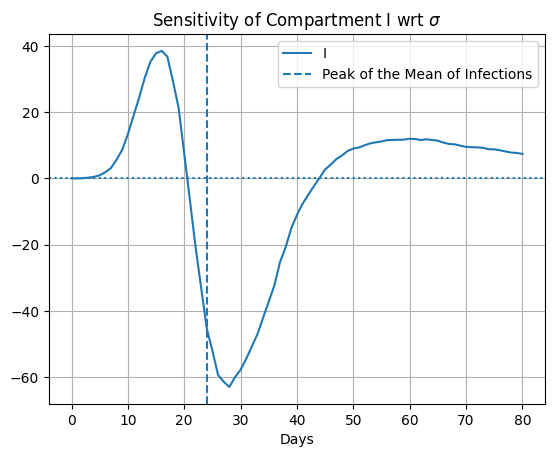

In [5]:
for param_index,param_name in enumerate(theta_names): 

    theta_perturbed_plus = theta
    theta_perturbed_plus = theta_perturbed_plus.at[param_index].set(theta[param_index] + epsilon)
    full_state_perturbed_plus = jax.vmap(model, in_axes=(None, None, 0, None, None))(
        x0, theta_perturbed_plus, keys, days, delta_t
    )

    theta_perturbed_minus = theta
    theta_perturbed_minus = theta_perturbed_minus.at[param_index].set(theta[param_index] - epsilon)
    full_state_perturbed_minus = jax.vmap(model, in_axes=(None, None, 0, None, None))(
        x0, theta_perturbed_minus, keys, days, delta_t
    )

    state_index = 1
    full_state_mean = jnp.mean(jax.vmap(model, in_axes=(None, None, 0, None, None))(
        x0, theta, keys, days, delta_t
    ),axis = 0)

    peak_index = full_state_mean[:,1].argmax()

    s_est = jnp.mean(
        (
            full_state_perturbed_plus[:, :, :]
            - full_state_perturbed_minus[:, :, :]
        )
        / (2*epsilon),
        axis=0,
    )

    labels = ['S','I','R','$\\beta$']
    plt.title(f'Sensitivity of Compartment {labels[state_index]} wrt {param_name}')
    plt.plot(jnp.arange(0,days + 1,1),s_est[:,state_index],label = labels[state_index])
    plt.axvline(peak_index,ls = 'dashed',label = 'Peak of the Mean of Infections')
    plt.axhline(y = 0,ls = 'dotted')
    plt.xlabel('Days')
    plt.grid()
    plt.legend()
    plt.show()

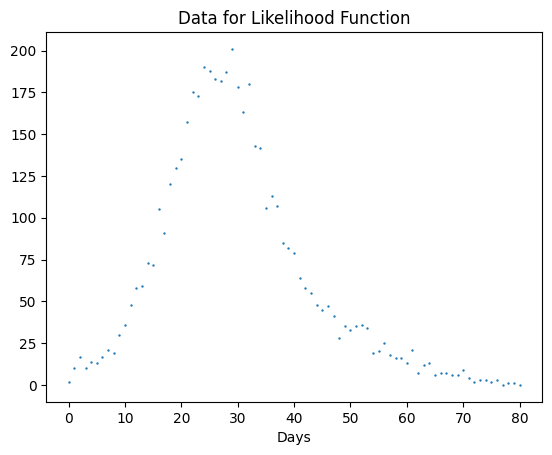

In [6]:
'''Now for Sensitivity Analysis of a Likelihood Function'''

key_real_data = jax.random.key(0)
real_data = model(
        x0, theta, key_real_data, days, delta_t
    )

observations = real_data[:,1]
noise_key,key_real_data = jax.random.split(key_real_data)
observations = jax.random.poisson(noise_key,observations)

plt.title('Data for Likelihood Function')
plt.scatter(jnp.arange(0,days + 1,1),observations,s = 0.5)
plt.xlabel('Days')
plt.show()

In [7]:
# def log_likelihood(params, key, N):
#     keys = jax.random.split(key, N)
#     return jnp.sum(
#             jax.scipy.stats.poisson.logpmf(
#                 observations,
#                 jax.vmap(model, in_axes=(None, None, 0, None, None))(
#                     x0, params, keys, days, delta_t
#                 )[..., 1]
#                 + 0.005,
#             ),
#             axis=1,
#         )

# def log_likelihood_batched(params,key,N,batch_size): 
#     batches = []
#     num_batches = N//batch_size if N//batch_size > 0 else 1
#     batch_size = batch_size if num_batches != 1 else N
#     for _ in range(num_batches): 
#         batch_key,key = jax.random.split(key,2)
#         LL = log_likelihood(params, batch_key, batch_size)
#         batches.append(LL)

#     batches = jnp.array(batches).reshape(-1)
#     return jnp.mean(batches,axis = 0)
    

# num_model_sched = [10_000, 100_000, 1_000_000,10_000_000]
# batch_size = 100_000

# for param_index, param_name in enumerate(theta_names):
#     plt.title(f"Derivative of Log-Likelihood wrt {param_name}")
#     theta_perturbed = theta
#     theta_perturbed = theta_perturbed.at[param_index].set(theta[param_index] + epsilon)
#     for num_models in num_model_sched:
#         ll_key, key_real_data = jax.random.split(key_real_data)
#         ll_s_est = (
#             log_likelihood_batched(theta_perturbed, ll_key, num_models,batch_size)
#             - log_likelihood_batched(theta, ll_key, num_models,batch_size)
#         ) / epsilon
#         plt.axhline(0,ls = 'dotted')
#         plt.scatter(num_models, ll_s_est, color="blue")

#     plt.xscale("log")
#     plt.xlabel("Number of Models")
#     plt.show()